# 02 — Preprocess CDFG JSON → PyG tensors


In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
from ll_hls4ml.config import load_config
from ll_hls4ml.data.tensorize import create_graph_tensors
from ll_hls4ml.data.vocab import save_vocab, vocab_scan, load_vocab, make_local_types_global
from ll_hls4ml.viz.dataset import analyze_graph_dataset
from ll_hls4ml.viz.eda import plot_vocab_counts


In [37]:
cfg = load_config()

kernel_subset = ["2layer", "conv1d", "conv2d"]  # extend as needed
max_archives = 1

In [38]:
from ll_hls4ml.io.discovery import iter_graph_paths
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import tqdm

graph_dir = cfg.graph_dir
paths = list(iter_graph_paths(graph_dir, kernel_subset, max_archives))

def process_graph(path):
    graph_path = path[1]
    ll_path = str(graph_path).replace("graphs", "ll").replace(".json", ".ll")
    make_local_types_global(graph_path, ll_path)

with ThreadPoolExecutor(max_workers=8) as executor:
    list(tqdm.tqdm(
        executor.map(process_graph, paths),
        total=len(paths),
        desc="Parsing graph files for building vocab",
    ))

Parsing graph files for building vocab: 100%|██████████| 175/175 [04:58<00:00,  1.71s/it]


Parsing graph files for building vocab: 100%|██████████| 26/26 [00:09<00:00,  2.75it/s]


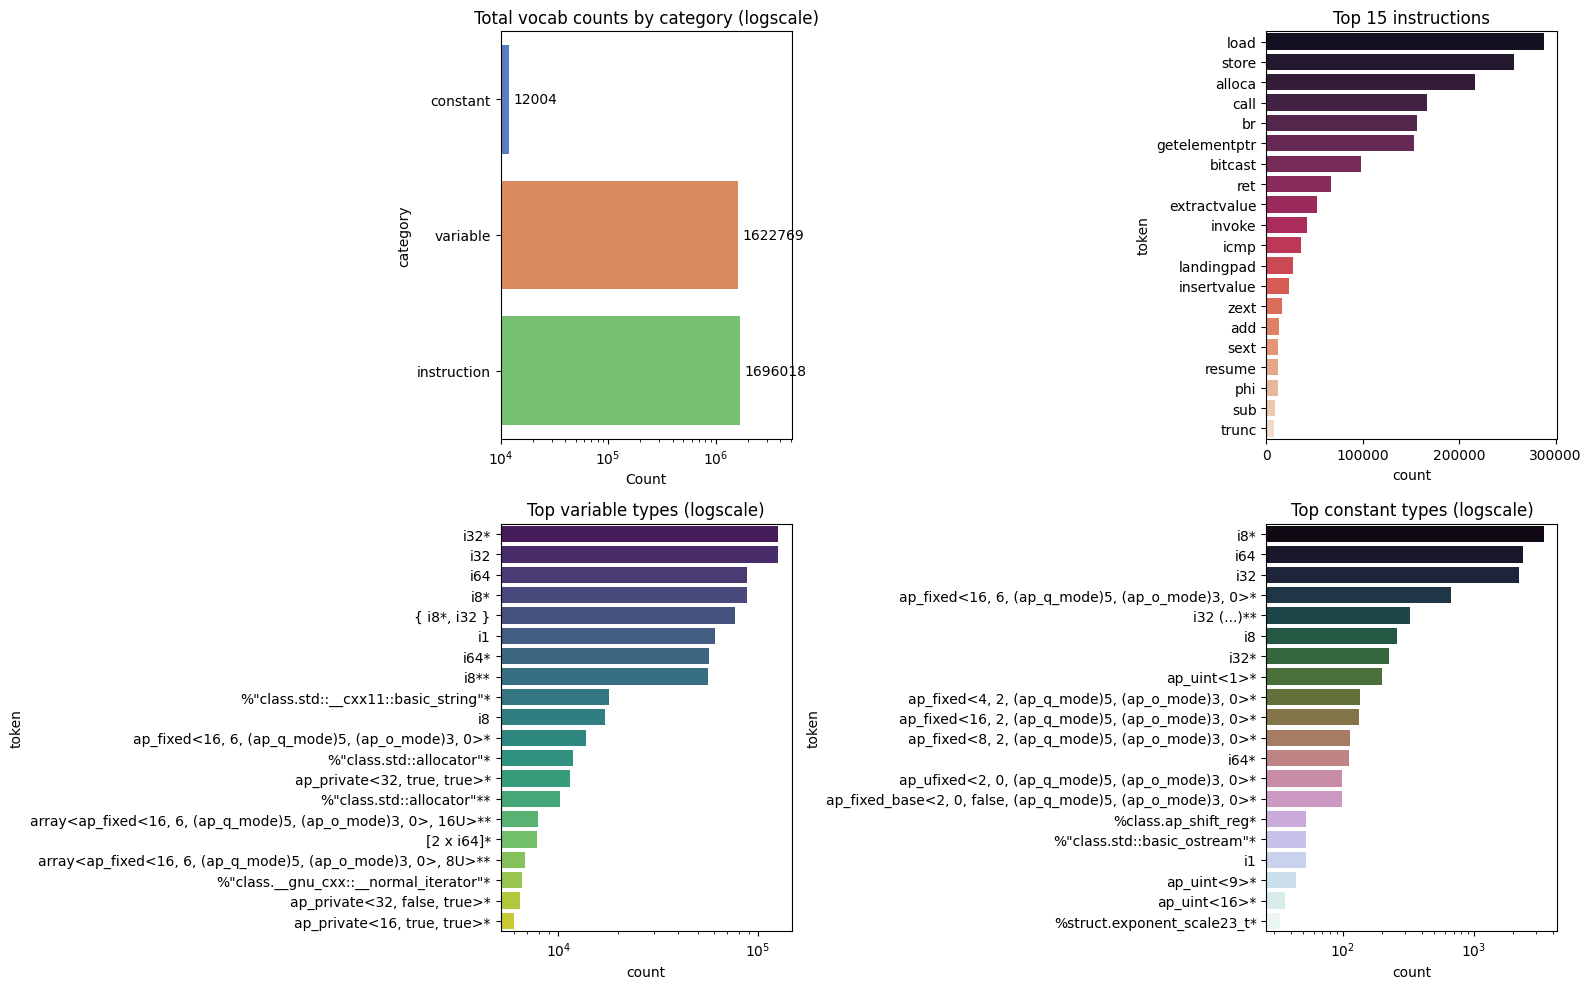

{'; undefined function': 1,
 'UNK': 0,
 '[external]': 2,
 'add': 3,
 'alloca': 4,
 'and': 5,
 'ashr': 6,
 'bitcast': 7,
 'br': 8,
 'call': 9,
 'extractvalue': 10,
 'getelementptr': 11,
 'icmp': 12,
 'insertvalue': 13,
 'invoke': 14,
 'landingpad': 15,
 'load': 16,
 'lshr': 17,
 'mul': 18,
 'or': 19,
 'phi': 20,
 'ptrtoint': 21,
 'resume': 22,
 'ret': 23,
 'sdiv': 24,
 'select': 25,
 'sext': 26,
 'shl': 27,
 'srem': 28,
 'store': 29,
 'sub': 30,
 'switch': 31,
 'trunc': 32,
 'udiv': 33,
 'unreachable': 34,
 'urem': 35,
 'xor': 36,
 'zext': 37}
8
{'constant': {'%"class.std::__cxx11::basic_string"*': 26,
              '%"class.std::basic_ostream"*': 52,
              '%class.ap_shift_reg*': 52,
              '%class.ap_shift_reg.149*': 2,
              '%class.ap_shift_reg.168*': 2,
              '%class.ap_shift_reg.172*': 2,
              '%class.ap_shift_reg.179*': 4,
              '%class.ap_shift_reg.187*': 2,
              '%class.ap_shift_reg.189*': 2,
              '%class.ap_shif

In [35]:
instruction_vocab, max_pos, vocab_counts = vocab_scan(
    cfg.graph_dir, kernel_subset=kernel_subset, max_archives=max_archives
)
# save_vocab(instruction_vocab, max_pos, "../artifacts/vocab/new_vocab.json", vocab_counts=vocab_counts)
# instruction_vocab, max_pos, vocab_counts = load_vocab("../artifacts/vocab/new_vocab.json")
plot_vocab_counts(vocab_counts)
from pprint import pprint
pprint(instruction_vocab)
print(max_pos)
pprint(vocab_counts)


In [39]:
create_graph_tensors(cfg.graph_dir, cfg.tensor_dir, instruction_vocab, kernel_subset=kernel_subset, max_archives=max_archives, n_workers=8)

Processing graph files into PyTorch tensors: 100%|██████████| 175/175 [01:58<00:00,  1.48it/s]


Types not parsed by embedder:
   175  %struct._Guard*
   175  %"class.std::basic_istream"**
   175  %"class.std::__new_allocator"**
   175  %struct._IO_FILE*
   175  %"class.std::__new_allocator"*
   175  %struct._private_range_ref**
   175  %"class.std::basic_ifstream"*
   175  %"class.std::allocator"**
   175  %"class.std::__cxx11::basic_istringstream"*
   175  %"class.std::__cxx11::basic_string"*
   175  %"class.std::basic_ostream"*
   175  %struct._private_bit_ref**
   175  %struct._private_bit_ref*
   175  %struct._Guard**
   175  %"struct.std::__cxx11::basic_string<char>::_Alloc_hider"**
   175  %"class.std::__cxx11::basic_string"**
   175  { i8*, i32 }
   175  %union.anon*
   175  %"class.std::allocator"*
   175  %struct._IO_FILE**
   175  %"class.std::basic_istream"*
   175  %"class.std::basic_ios"*
   175  %"class.std::__cxx11::basic_istringstream"**
   175  %struct._private_range_ref*
   175  %"struct.std::__cxx11::basic_string<char>::_Alloc_hider"*
    75  %"class.std::deque